In [20]:
import yaml
import json
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from planner_copy import PlanningEngine


PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd() / "Path_Optimizer"]


def resolve_project_path(path: str) -> Path:
    relative_path = Path(path)
    for root in PROJECT_ROOT_CANDIDATES:
        candidate = root / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find '{path}' from {Path.cwd()}")


def load_yaml(path: str) -> dict:
    with open(resolve_project_path(path), "r") as f:
        return yaml.safe_load(f)


def load_json(path: str) -> dict:
    with open(resolve_project_path(path), "r") as f:
        return json.load(f)

def initial_state(config: dict) -> np.ndarray:
    state = np.zeros(13, dtype=float)
    state[0:3] = np.asarray(config["X_0"]["p_0"], dtype=np.float64)
    state[3:6] = np.asarray(config["X_0"]["v_0"], dtype=np.float64)
    state[6:10] = np.asarray(config["X_0"]["q_0"], dtype=np.float64)
    state[6:10] /= np.linalg.norm(state[6:10])
    state[10:13] = np.asarray(config["X_0"]["omega_0"], dtype=np.float64)
    return state


def extract_gate_positions(course: dict) -> np.ndarray:
    gates = course["targets"]
    key = "position_cm"
    

    positions: list[list[float]] = []
    for item in gates:
        position = item if key is None else item.get(key) or item.get("position")
        
        positions.append(
            [
                float(position["x"]) * 0.01,
                float(position["y"]) * 0.01,
                float(position["z"]) * 0.01,
            ]
        )

    return np.asarray(positions, dtype=float)

In [21]:
quad_params = load_yaml("../src/quadrotor/params.yaml")
sim_config = load_yaml("../src/sim/config.yaml")
course_path = "../course_model/targets-SimBlank-20260216_194648.json"
course = load_json(course_path)

planner = PlanningEngine(params=quad_params)

state = initial_state(sim_config)
gates = extract_gate_positions(course)

reference_trajectory = planner.generate_initial_guess(gates[:3], x0=state, nodes_per_segment=3)

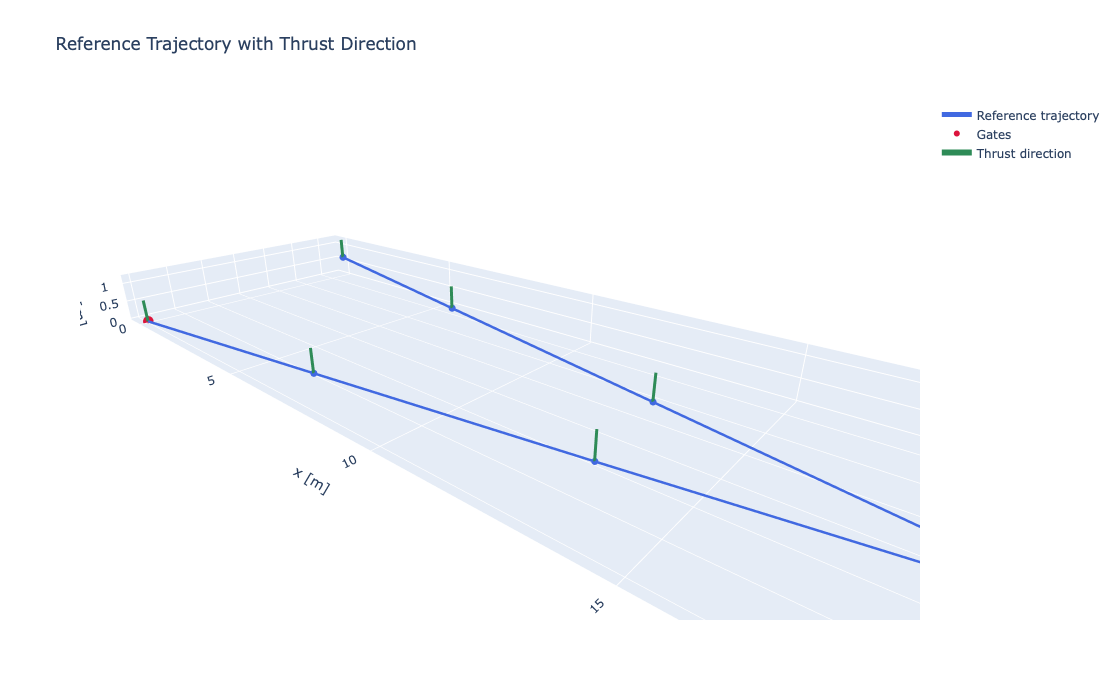

In [22]:
import plotly.graph_objects as go

trajectory_states = np.asarray(reference_trajectory["x"], dtype=float)
positions = trajectory_states[:, 0:3]
quaternions = trajectory_states[:, 6:10]


def quaternion_to_rotation_matrix(q: np.ndarray) -> np.ndarray:
    qw, qx, qy, qz = q / np.linalg.norm(q)
    return np.array(
        [
            [1.0 - 2.0 * (qy * qy + qz * qz), 2.0 * (qx * qy - qw * qz), 2.0 * (qx * qz + qw * qy)],
            [2.0 * (qx * qy + qw * qz), 1.0 - 2.0 * (qx * qx + qz * qz), 2.0 * (qy * qz - qw * qx)],
            [2.0 * (qx * qz - qw * qy), 2.0 * (qy * qz + qw * qx), 1.0 - 2.0 * (qx * qx + qy * qy)],
        ],
        dtype=float,
    )


thrust_body = np.array([0.0, 0.0, 1.0], dtype=float)
thrust_directions = np.array([
    quaternion_to_rotation_matrix(q) @ thrust_body for q in quaternions
])

num_vectors = min(12, len(positions))
vector_indices = np.unique(np.linspace(0, len(positions) - 1, num_vectors, dtype=int))
span = np.ptp(positions, axis=0)
vector_scale = max(float(np.max(span)) * 0.03, 0.08)

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=positions[:, 0],
        y=positions[:, 1],
        z=positions[:, 2],
        mode="lines+markers",
        name="Reference trajectory",
        line=dict(color="royalblue", width=5),
        marker=dict(size=4),
    )
)

fig.add_trace(
    go.Scatter3d(
        x=gates[:2, 0],
        y=gates[:2, 1],
        z=gates[:2, 2],
        mode="markers",
        name="Gates",
        marker=dict(size=6, color="crimson"),
    )
)

for i, idx in enumerate(vector_indices):
    start = positions[idx]
    end = start + vector_scale * thrust_directions[idx]
    fig.add_trace(
        go.Scatter3d(
            x=[start[0], end[0]],
            y=[start[1], end[1]],
            z=[start[2], end[2]],
            mode="lines",
            name="Thrust direction" if i == 0 else None,
            showlegend=(i == 0),
            line=dict(color="seagreen", width=6),
        )
    )

fig.update_layout(
    title="Reference Trajectory with Thrust Direction",
    scene=dict(
        xaxis_title="x [m]",
        yaxis_title="y [m]",
        zaxis_title="z [m]",
        aspectmode="data",
        camera=dict(eye=dict(x=1.4, y=-1.6, z=0.9)),
    ),
    width=900,
    height=700,
)

fig.show()


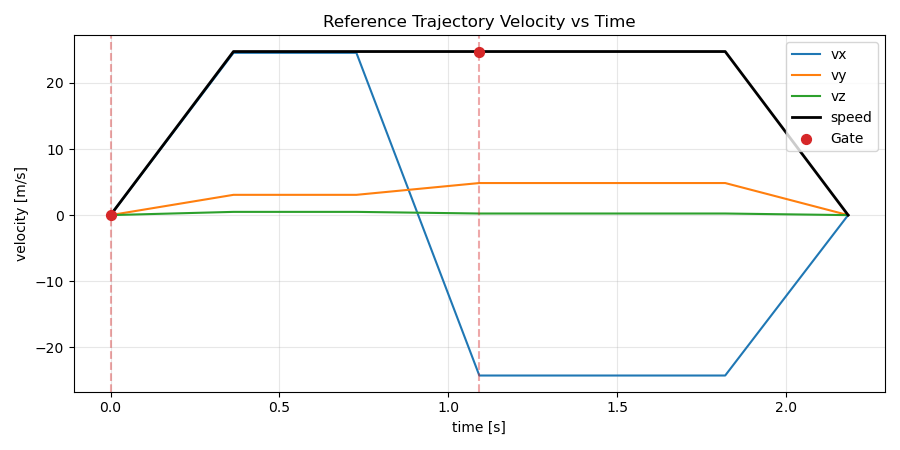

In [23]:
times = np.asarray(reference_trajectory["t"], dtype=float)
trajectory_states = np.asarray(reference_trajectory["x"], dtype=float)
positions = trajectory_states[:, 0:3]
velocities = trajectory_states[:, 3:6]
speed = np.linalg.norm(velocities, axis=1)
gate_positions = gates[:2]
gate_indices = [np.argmin(np.linalg.norm(positions - gate, axis=1)) for gate in gate_positions]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(times, velocities[:, 0], label="vx")
ax.plot(times, velocities[:, 1], label="vy")
ax.plot(times, velocities[:, 2], label="vz")
ax.plot(times, speed, label="speed", color="black", linewidth=2)

for i, gate_idx in enumerate(gate_indices):
    gate_time = times[gate_idx]
    gate_speed = speed[gate_idx]
    ax.axvline(gate_time, color="tab:red", linestyle="--", alpha=0.4)
    ax.scatter(gate_time, gate_speed, color="tab:red", s=50, zorder=5, label="Gate" if i == 0 else None)

ax.set_title("Reference Trajectory Velocity vs Time")
ax.set_xlabel("time [s]")
ax.set_ylabel("velocity [m/s]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


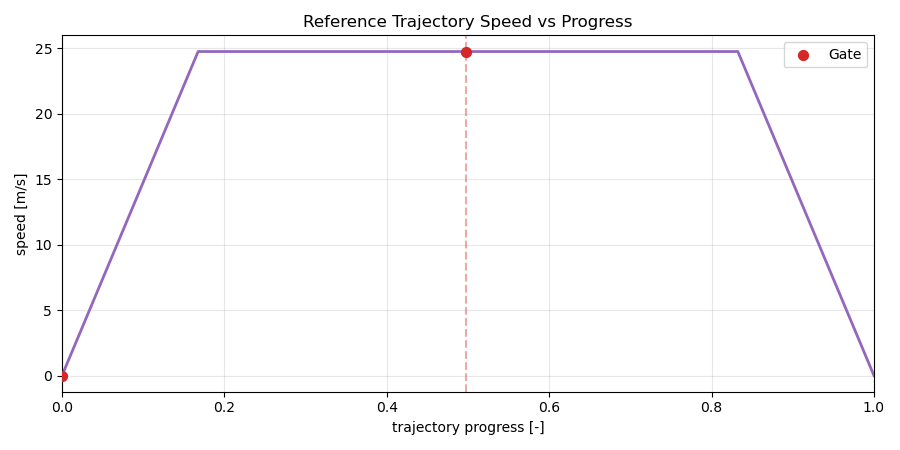

In [24]:
trajectory_states = np.asarray(reference_trajectory["x"], dtype=float)
positions = trajectory_states[:, 0:3]
velocities = trajectory_states[:, 3:6]
speed = np.linalg.norm(velocities, axis=1)
gate_positions = gates[:2]

segment_lengths = np.linalg.norm(np.diff(positions, axis=0), axis=1)
cumulative_distance = np.concatenate(([0.0], np.cumsum(segment_lengths)))
progress = cumulative_distance / cumulative_distance[-1] if cumulative_distance[-1] > 0 else cumulative_distance
gate_indices = [np.argmin(np.linalg.norm(positions - gate, axis=1)) for gate in gate_positions]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(progress, speed, color="tab:purple", linewidth=2)

for i, gate_idx in enumerate(gate_indices):
    gate_progress = progress[gate_idx]
    gate_speed = speed[gate_idx]
    ax.axvline(gate_progress, color="tab:red", linestyle="--", alpha=0.4)
    ax.scatter(gate_progress, gate_speed, color="tab:red", s=50, zorder=5, label="Gate" if i == 0 else None)

ax.set_title("Reference Trajectory Speed vs Progress")
ax.set_xlabel("trajectory progress [-]")
ax.set_ylabel("speed [m/s]")
ax.set_xlim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
